# Factors related to Internet usage in the Czech Republic

The aim of this project is to study the relationship of various factors with the use of the Internet in the Czech Republic. 

### The plan of this notebook:
- **Exploratory Data Analysis:** filtering, converting variables to the correct data types, cleaning missing values
- **Exploratory Factor Analysis:** creating factor variables from the original narrowly focused variables
- **Linear Regression Analysis:** investigation of the relationship between predictor variables and the target variable (Internet Usage)

### Setup

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.spatial.distance import mahalanobis
from scipy.stats import shapiro, skew, kurtosis, kstest, normaltest, chi2

import warnings
warnings.filterwarnings('ignore')

## Dataset

For our research, we will use data on the Czech Republic from the ESS10 dataset (European Social Survey European Research Infrastructure (ESS ERIC), 2025), focusing on the topics of Democracy and Digital social contacts.

In [24]:
ess10 = pd.read_csv('ESS10e03_3.csv')
czechia = ess10[ess10['cntry'] == 'CZ'].copy()
czechia

,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,vinwe,inwde,jinws,jinwe,inwtm,mode,domain,prob,stratum,psu
5582,ESS10e03_3,10,3.3,02.12.2025,10004,CZ,1.031935,1.108297,0.362764,0.402050,...,2021-08-10 13:13:00,2021-08-10 13:14:00,2021-08-10 13:14:00,2021-08-10 13:16:00,47.0,1,NaN,0.000365,305,5411
5583,ESS10e03_3,10,3.3,02.12.2025,10009,CZ,0.515968,0.625438,0.362764,0.226886,...,2021-07-24 21:04:00,2021-07-24 21:09:00,2021-07-24 21:09:00,2021-07-24 21:12:00,57.0,1,NaN,0.000730,330,5648
5584,ESS10e03_3,10,3.3,02.12.2025,10019,CZ,0.515968,0.318503,0.362764,0.115542,...,2021-07-30 19:05:00,2021-07-30 19:06:00,2021-07-30 19:06:00,2021-07-30 19:07:00,58.0,1,NaN,0.000730,299,5621
5585,ESS10e03_3,10,3.3,02.12.2025,10038,CZ,1.031935,1.283641,0.362764,0.465659,...,2021-07-20 15:33:00,2021-07-20 15:41:00,2021-07-20 15:41:00,2021-07-20 15:44:00,42.0,1,NaN,0.000365,290,5634
5586,ESS10e03_3,10,3.3,02.12.2025,10052,CZ,0.515968,0.554148,0.362764,0.201025,...,2021-08-08 16:22:00,2021-08-08 16:33:00,2021-08-08 16:33:00,2021-08-08 16:37:00,42.0,1,NaN,0.000730,305,5411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8053,ESS10e03_3,10,3.3,02.12.2025,27877,CZ,2.063870,2.243718,0.362764,0.813940,...,2021-08-25 15:34:00,2021-08-25 15:36:00,2021-08-25 15:36:00,2021-08-25 15:38:00,56.0,1,NaN,0.000183,293,5576
8054,ESS10e03_3,10,3.3,02.12.2025,27880,CZ,1.031935,1.114818,0.362764,0.404416,...,2021-08-26 16:18:00,2021-08-26 16:23:00,2021-08-26 16:23:00,2021-08-26 16:24:00,41.0,1,NaN,0.000365,341,5808
8055,ESS10e03_3,10,3.3,02.12.2025,27889,CZ,0.515968,0.403736,0.362764,0.146461,...,2021-08-20 19:08:00,2021-08-20 19:12:00,2021-08-20 19:12:00,2021-08-20 19:14:00,54.0,1,NaN,0.000730,317,5815
8056,ESS10e03_3,10,3.3,02.12.2025,27895,CZ,1.031935,1.145842,0.362764,0.415670,...,2021-08-22 18:50:00,2021-08-22 18:52:00,2021-08-22 18:52:00,2021-08-22 18:56:00,54.0,1,NaN,0.000365,311,5406


# Exploratory Data Analysis (EDA)

### Variables for the analyses

To conduct an **exploratory data analysis**, we need to understand which variables we have to work with in a **linear regression** further.

We will use **netustm** (Internet use, how much time on typical day, in minutes) as a target variable.

The following variables will be used as predictors:

- **gndr** (categorical binary), a control variable - gender of respondent
- **agea** (numeric continuous), a control variable - age of respondent, calculated
- **happy** (quasi-numeric) - how happy is respondent
- **sclact_ord** (categorical ordinal) - if respondent takes part in social activities compared to others of same age
- **social trust** (quasi-numeric) - this variable will be calculated later as a mean of ppltrst, pplfair and pplhlp variables
- **variables for human values** (numeric continuous) - these variables will be calculated later as a result of factor analysis with variables ipcrtiv, imprich, ipeqopt, ipshabt, impsafe, impdiff, ipfrule, ipudrst, ipmodst, ipgdtim, impfree, iphlppl, ipsuces, ipstrgv, ipadvnt, ipbhprp, iprspot, iplylfr, impenv, imptrad, impfun

We will leave only the variables necessary for further analysis:

In [25]:
vars_for_analysis = [
    'netustm', 'gndr', 'agea', 'happy', 'sclact', 
    'ppltrst', 'pplfair', 'pplhlp',
    'ipcrtiv', 'imprich', 'ipeqopt', 'ipshabt', 'impsafe', 
    'impdiff', 'ipfrule', 'ipudrst', 'ipmodst', 'ipgdtim', 
    'impfree', 'iphlppl', 'ipsuces', 'ipstrgv', 'ipadvnt', 
    'ipbhprp', 'iprspot', 'iplylfr', 'impenv', 'imptrad', 
    'impfun'
]

czechia = czechia[vars_for_analysis].copy()

### Correcting variable types and handling missing values

Now let's correct the variable types and remove the missing values from the variables we need. The missing values are encoded as specific numbers, according to the codebook.

In [26]:
czechia['netustm'] = pd.to_numeric(czechia['netustm'])
czechia['netustm'] = czechia['netustm'].replace([6666, 7777, 8888, 9999], np.nan)

czechia['gndr'] = czechia['gndr'].map({1: 'Male', 2: 'Female'})

czechia['agea'] = pd.to_numeric(czechia['agea'])
czechia['agea'] = czechia['agea'].replace(999, np.nan)

czechia['happy'] = pd.to_numeric(czechia['happy'])
czechia['happy'] = czechia['happy'].replace([77, 88, 99], np.nan)

czechia['sclact'] = pd.to_numeric(czechia['sclact'])
czechia['sclact'] = czechia['sclact'].where(czechia['sclact'].between(1, 5))
sclact_labels = {
    1: 'Much less than most',
    2: 'Less than most', 
    3: 'About the same',
    4: 'More than most',
    5: 'Much more than most'
}
czechia['sclact_ord'] = pd.Categorical(
    czechia['sclact'].map(sclact_labels),
    categories=['Much less than most', 'Less than most', 'About the same', 
                'More than most', 'Much more than most'],
    ordered=True
)

for var in ['ppltrst', 'pplfair', 'pplhlp']:
    czechia[var] = pd.to_numeric(czechia[var])
    czechia[var] = czechia[var].replace([77, 88, 99], np.nan)

human_values_vars = [
    'ipcrtiv', 'imprich', 'ipeqopt', 'ipshabt', 'impsafe', 
    'impdiff', 'ipfrule', 'ipudrst', 'ipmodst', 'ipgdtim', 
    'impfree', 'iphlppl', 'ipsuces', 'ipstrgv', 'ipadvnt', 
    'ipbhprp', 'iprspot', 'iplylfr', 'impenv', 'imptrad', 
    'impfun'
]

for var in human_values_vars:
    czechia[var] = pd.to_numeric(czechia[var])
    czechia[var] = czechia[var].replace([7, 8, 9], np.nan)

In [27]:
cz = czechia.dropna()
cz

,netustm,gndr,agea,happy,sclact,ppltrst,pplfair,pplhlp,ipcrtiv,imprich,...,ipsuces,ipstrgv,ipadvnt,ipbhprp,iprspot,iplylfr,impenv,imptrad,impfun,sclact_ord
5582,360.0,Male,60,8.0,3.0,3.0,3.0,3.0,1.0,3.0,...,3.0,1.0,4.0,3.0,1.0,1.0,1.0,1.0,4.0,About the same
5585,60.0,Male,61,3.0,3.0,7.0,7.0,6.0,3.0,4.0,...,3.0,1.0,5.0,4.0,4.0,2.0,2.0,2.0,2.0,About the same
5586,60.0,Male,56,6.0,1.0,6.0,6.0,6.0,4.0,3.0,...,3.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,Much less than most
5587,240.0,Male,38,9.0,4.0,7.0,9.0,9.0,1.0,1.0,...,1.0,1.0,1.0,4.0,1.0,2.0,1.0,2.0,1.0,More than most
5591,360.0,Male,39,5.0,4.0,5.0,6.0,5.0,2.0,3.0,...,2.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,More than most
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8049,120.0,Male,52,8.0,3.0,4.0,6.0,5.0,1.0,2.0,...,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,About the same
8050,60.0,Female,48,8.0,3.0,8.0,8.0,8.0,3.0,4.0,...,5.0,1.0,5.0,1.0,3.0,2.0,2.0,3.0,3.0,About the same
8053,270.0,Male,47,7.0,3.0,4.0,4.0,4.0,2.0,2.0,...,3.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,3.0,About the same
8056,90.0,Male,61,6.0,1.0,9.0,9.0,6.0,3.0,4.0,...,5.0,4.0,5.0,3.0,5.0,3.0,3.0,3.0,4.0,Much less than most


The final dataset contains a total of 1,490 observations, which will serve as the basis for further analysis.

### Creating an additional variable

Let's create a variable **social_trust** as a mean of ppltrst, pplfair and pplhlp variables:
- ppltrst - Most people can be trusted or you can't be too careful
- pplfair - Most people try to take advantage of you, or try to be fair
- pplhlp - Most of the time people helpful or mostly looking out for themselves

In all of these variables higher values mean higher trust in people.

In [28]:
cz['social_trust'] = cz[['ppltrst', 'pplfair', 'pplhlp']].mean(axis=1)

Thus, we now have a dataset for the Czech Republic that has been cleaned of missing values and contains the main necessary variables of the correct data types.

We will create the remaining variables (which we need as predictors for linear regression) using factor analysis.

## Exploratory Factor Analysis

Before performing linear regression, we will conduct a factor analysis to identify the main human values, which we will then use as predictors. To do this, we will select the following variables.

### Variables for exploratory factor analysis:

- ipcrtiv - Important to think new ideas and being creative
- imprich - Important to be rich, have money and expensive things
- ipeqopt - Important that people are treated equally and have equal opportunities
- ipshabt - Important to show abilities and be admired
- impsafe - Important to live in secure and safe surroundings
- impdiff - Important to try new and different things in life
- ipfrule - Important to do what is told and follow rules
- ipudrst - Important to understand different people
- ipmodst - Important to be humble and modest, not draw attention
- ipgdtim - Important to have a good time
- impfree - Important to make own decisions and be free
- iphlppl - Important to help people and care for others well-being
- ipsuces - Important to be successful and that people recognise achievements
- ipstrgv - Important that government is strong and ensures safety
- ipadvnt - Important to seek adventures and have an exciting life
- ipbhprp - Important to behave properly
- iprspot - Important to get respect from others
- iplylfr - Important to be loyal to friends and devote to people close
- impenv - Important to care for nature and environment
- imptrad - Important to follow traditions and customs
- impfun - Important to seek fun and things that give pleasure

In [29]:
human_values = cz[human_values_vars].copy()

### Assumptions for exploratory factor analysis

First, let's check the assumptions of factor analysis to make sure we can perform it on this data and that the results will be reliable.

In [30]:
p = human_values.shape[1]

# 1. Factorability (KMO & Bartlett)
kmo = calculate_kmo(human_values)[1]
_, p_bart = calculate_bartlett_sphericity(human_values)

# 2. No Singularity (Condition Number)
cond = np.linalg.cond(human_values.corr())

# 3. Multivariate Normality (Henze-Zirkler)
p_norm = pg.multivariate_normality(human_values)[1]

# 4. No Multivariate Outliers (Mahalanobis)
mahal_sq = np.sum((human_values - human_values.mean()) @ np.linalg.inv(human_values.cov()) * (human_values - human_values.mean()), axis=1)
outliers = (chi2.sf(mahal_sq, p) < 0.001).sum()

print(f"N:{len(human_values)} | KMO:{kmo:.2f} | Bartlett p:{p_bart:.2e} | Cond:{cond:.1f} | Norm p:{p_norm:.2e} | Outliers:{outliers}")

N:1490 | KMO:0.92 | Bartlett p:0.00e+00 | Cond:22.0 | Norm p:0.00e+00 | Outliers:0


The sample size is sufficient, consisting of 1,490 observations. A very high KMO value and a low p-value in Bartlett’s test mean that the variables we selected are correlated with one another and share common variance, which is ideal for exploratory factor analysis. Also, there is no singularity (no perfect multicollinearity), so there are no variables measuring the same thing. Finally, there are 0 outliers in the data, which is also excellent for our analysis.

However, according to Henze-Zirkler, the assumption of multivariate normality is violated, which means we will need to use Principal Axis Factoring (PAF) as the extraction method, since, unlike Maximum Likelihood (ML), it does not require the data to be normally distributed.

Let’s test the final assumption of exploratory factor analysis: linearity. To do this, we’ll calculate the Spearman and Pearson correlations and compare them. If the difference between them is large (greater than 0.1 in absolute value), and the relationship is at least moderate, then Spearman’s correlation likely captures certain relationships that Pearson’s correlation (which is designed for linear relationships) does not capture. This means that it is likely that there are nonlinear relationships between the variables.

In [31]:
# 5. Linearity
pearson_corr = human_values[human_values_vars].corr(method='pearson')
spearman_corr = human_values[human_values_vars].corr(method='spearman')

diff = abs(pearson_corr) - abs(spearman_corr)

non_linear_pairs = []

for i in range(len(human_values_vars)):
    for j in range(i + 1, len(human_values_vars)):
        var1 = human_values_vars[i]
        var2 = human_values_vars[j]
        
        diff_val = diff.loc[var1, var2]
        spear_val = abs(spearman_corr.loc[var1, var2])
        pearson_val = abs(pearson_corr.loc[var1, var2])
        
        if diff_val > 0.10 and spear_val > 0.30:
            non_linear_pairs.append({
                'Variable 1': var1,
                'Variable 2': var2,
                'Pearson': round(pearson_val, 3),
                'Spearman': round(spear_val, 3),
                'Difference': round(diff_val, 3)
            })

print(f'Non-Linear Relationship: {pd.DataFrame(non_linear_pairs)}')

Non-Linear Relationship: Empty DataFrame
Columns: []
Index: []


None of the pairs show sufficiently large discrepancies between Pearson’s correlation and Spearman’s correlation, which means that the assumption of linearity is likely met.

Thus, we can conduct an exploratory factor analysis using Principal Axis Factoring.

## Conducting a Factor Analysis

#### The number of factors



To begin with, let’s determine the possible number of factors in our data. It should be noted that since all variables for factor analysis have the same scales, standardization is not required for further steps.

Eigenvalues for all factors:
  Factor 1: 7.0635
  Factor 2: 2.9800
  Factor 3: 1.2945
  Factor 4: 1.0008
  Factor 5: 0.9313
  Factor 6: 0.6983
  Factor 7: 0.6545
  Factor 8: 0.6343
  Factor 9: 0.6151
  Factor 10: 0.5504

Kaiser criterion: 4 factors


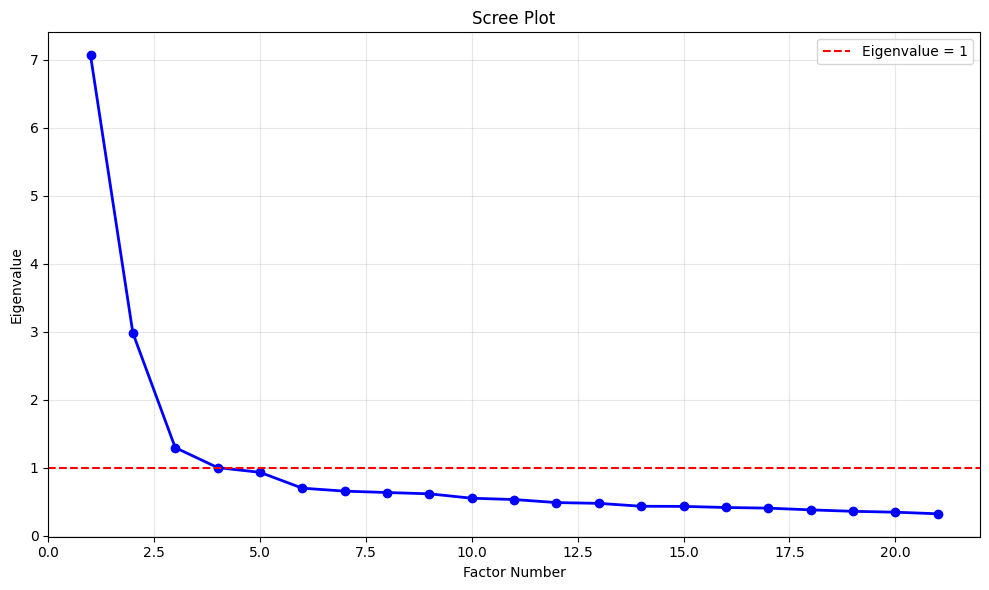

In [32]:
fa = FactorAnalyzer(rotation=None, n_factors=len(human_values_vars))
fa.fit(human_values)

# Eigenvalues
eigenvalues, _ = fa.get_eigenvalues()
print("Eigenvalues for all factors:")
for i, val in enumerate(eigenvalues[:10], 1):
    print(f"  Factor {i}: {val:.4f}")

# Kaiser criterion
n_factors_kaiser = np.sum(eigenvalues > 1)
print(f"\nKaiser criterion: {n_factors_kaiser} factors")

# Scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'bo-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Four of the eigenvalues turned out to be greater than one, so we will presumably be extracting four factors from our variables.

#### Model training (Varimax)

Now we will initialize and train the model using orthogonal Varimax rotation, since we will use the resulting factors in linear regression and they should not be correlated.

In [33]:
fa_paf = FactorAnalyzer(method='principal', rotation='varimax', n_factors=4)
fa_paf.fit(human_values)

FactorAnalyzer(method='principal', n_factors=4, rotation='varimax',
               rotation_kwargs={})

#### Interpretation of the factor loadings

In [34]:
loadings = fa_paf.loadings_

df_loadings = pd.DataFrame(
    loadings, 
    columns=[f'Factor {i+1}' for i in range(4)], 
    index=human_values.columns
)

print("Factor loadings:")
print(df_loadings.round(3))

Factor loadings:
         Factor 1  Factor 2  Factor 3  Factor 4
ipcrtiv     0.520     0.441    -0.003     0.077
imprich    -0.077     0.720     0.143    -0.058
ipeqopt     0.578     0.022     0.111     0.355
ipshabt    -0.005     0.754     0.191     0.015
impsafe     0.460    -0.055     0.540     0.218
impdiff     0.336     0.666     0.052     0.091
ipfrule    -0.026     0.192     0.403     0.673
ipudrst     0.453     0.085     0.047     0.642
ipmodst     0.149    -0.103     0.091     0.799
ipgdtim     0.368     0.684     0.046    -0.021
impfree     0.666     0.349     0.150    -0.059
iphlppl     0.589     0.149     0.264     0.388
ipsuces     0.149     0.716     0.228     0.111
ipstrgv     0.475     0.124     0.646     0.008
ipadvnt     0.034     0.792    -0.023     0.064
ipbhprp     0.066     0.048     0.643     0.506
iprspot     0.159     0.406     0.645     0.044
iplylfr     0.648     0.153     0.398     0.143
impenv      0.650     0.134     0.378     0.118
imptrad     0.274     0

We can see that all variables showed significant loadings (>0.40) on the corresponding factors.

Let's take a look at the four factors we obtained as a result of the factor analysis.

1) **Self-Expression & Care for Others**

- impfree - Make own decisions and be free (0.666)

- impenv - Care for nature and environment (0.650)

- iplylfr - Loyal to friends, devote to people close (0.648)

- iphlppl - Help people and care for others' well-being (0.589)

- ipeqopt - Equal treatment and equal opportunities (0.578)

- ipcrtiv - Think new ideas and being creative (0.520)

- ipstrgv - Strong government ensures safety (0.475)

- impsafe - Live in secure and safe surroundings (0.460)

2) **Hedonism & Achievement**

- ipadvnt - Seek adventures and exciting life (0.792)

- ipshabt - Show abilities and be admired (0.754)

- imprich - Be rich, have money and expensive things (0.720)

- ipsuces - Be successful, people recognise achievements (0.716)

- impfun - Seek fun and things that give pleasure (0.690)

- ipgdtim - Have a good time (0.684)

- impdiff - Try new and different things in life (0.666)

- iprspot - Get respect from others (0.406)

3) **Conservatism**

- ipbhprp - Behave properly (0.643)

- imptrad - Follow traditions and customs (0.499)

4) **Social Conformity**

- ipmodst - Be humble and modest, not draw attention (0.799)

- ipfrule - Do what is told and follow rules (0.673)

- ipudrst - Understand different people (0.642) 

In [35]:
factor_labels = {
    0: 'Self-Expression & Care for Others',
    1: 'Hedonism & Achievement',
    2: 'Conservatism',
    3: 'Social Conformity'
}

scores = fa_paf.transform(human_values)
df_scores = pd.DataFrame(scores, columns=factor_labels.values())

#### Communalities

Now let’s look at the communality to understand how much of the variance in the variables is explained by the factors obtained.

In [36]:
communalities = fa_paf.get_communalities()
df_comm = pd.DataFrame({
    'Variable': human_values.columns,
    'Communalities': communalities
})

print(df_comm.round(3))

   Variable  Communalities
0   ipcrtiv          0.470
1   imprich          0.548
2   ipeqopt          0.473
3   ipshabt          0.605
4   impsafe          0.554
5   impdiff          0.567
6   ipfrule          0.653
7   ipudrst          0.627
8   ipmodst          0.679
9   ipgdtim          0.606
10  impfree          0.592
11  iphlppl          0.590
12  ipsuces          0.600
13  ipstrgv          0.658
14  ipadvnt          0.634
15  ipbhprp          0.676
16  iprspot          0.608
17  iplylfr          0.621
18   impenv          0.597
19  imptrad          0.421
20   impfun          0.560


The communality for all 21 variables is above 0.4, which means that the obtained factors describe these variables quite well.

#### Variance Expained

In [37]:
ev, prop_var, cum_var = fa_paf.get_factor_variance()

df_variance = pd.DataFrame({
    "Factor": [f"Factor {i+1}" for i in range(4)],
    "Eigenvalues (SS Loadings)": ev,
    "Proportion of Variance": prop_var,
    "Cumulative Variance": cum_var
})

print("Variance Expained:")
print(df_variance.round(3))

Variance Expained:
     Factor  Eigenvalues (SS Loadings)  Proportion of Variance  \
0  Factor 1                      3.368                   0.160   
1  Factor 2                      4.247                   0.202   
2  Factor 3                      2.481                   0.118   
3  Factor 4                      2.243                   0.107   

   Cumulative Variance  
0                0.160  
1                0.363  
2                0.481  
3                0.588  


Thus, each factor explains between 10% and 20% of the total variance, and all 4 factors together explain 58.8% of the total variance. This number indicates the adequacy of the identified 4‑factor structure.

#### Extracting factor scores

In [38]:
self_expression = df_scores['Self-Expression & Care for Others'].values
hedonism = df_scores['Hedonism & Achievement'].values
conservatism = df_scores['Conservatism'].values
social_conformity = df_scores['Social Conformity'].values

In [39]:
print(df_scores.describe())

       Self-Expression & Care for Others  Hedonism & Achievement  \
count                       1.490000e+03            1.490000e+03   
mean                        2.384372e-17           -4.232260e-17   
std                         1.000340e+00            1.000335e+00   
min                        -3.279931e+00           -2.499488e+00   
25%                        -6.459235e-01           -7.104354e-01   
50%                        -3.576571e-02           -4.894402e-02   
75%                         5.872895e-01            6.854738e-01   
max                         3.408889e+00            3.098922e+00   

       Conservatism  Social Conformity  
count  1.490000e+03       1.490000e+03  
mean  -1.442545e-16      -1.621373e-16  
std    1.000340e+00       1.000327e+00  
min   -3.375865e+00      -2.890978e+00  
25%   -7.063610e-01      -7.280724e-01  
50%   -1.669742e-02      -6.174843e-02  
75%    5.944513e-01       6.426583e-01  
max    3.563762e+00       3.725435e+00  


We extracted factor scores for each of the four dimensions identified through factor analysis with Varimax rotation. The scores are standardized (mean ≈ 0, SD ≈ 1), representing each respondent's position on the latent value dimensions: Self-Expression & Care for Others, Hedonism & Achievement, Conservatism, and Social Conformity. These variables will further serve as independent predictors in linear regression model, allowing us to examine how each value dimension is connected to Internet use.

# Linear regression

Now, we will perform a linear regression to determine which factors are associated with Internet use in the Czech Republic. Let's take a look at the variables we'll be using.

### A target variable:

**netustm** - Internet use, how much time on typical day, in minutes

### Predictors

The following variables will be used as predictors:

- **gndr** (categorical binary), a control variable
- **agea** (numeric continuous), a control variable
- **happy** (quasi-numeric)
- **sclact_ord** (categorical ordinal)
- **social trust** (quasi-numeric)
- **self_expression** (numeric continuous)
- **hedonism** (numeric continuous)
- **conservatism** (numeric continuous)
- **social_conformity** (numeric continuous)

All the variables were already described previously, so now we will perform linear regression analysis.

### Linear regression model

In [40]:
df = cz.copy()

df['self_expression'] = self_expression
df['hedonism'] = hedonism
df['conservatism'] = conservatism
df['social_conformity'] = social_conformity

control_vars = ['gndr', 'agea']
predictor_vars = ['self_expression', 'hedonism', 'conservatism', 'social_conformity', 
                  'happy', 'sclact_ord', 'social_trust']
target_var = 'netustm'

formula = 'netustm ~ gndr + agea + self_expression + hedonism + conservatism + social_conformity + happy + sclact_ord + social_trust'
model = smf.ols(formula, data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                netustm   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     17.79
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           3.19e-36
Time:                        17:37:17   Log-Likelihood:                -9640.0
No. Observations:                1490   AIC:                         1.931e+04
Df Residuals:                    1477   BIC:                         1.938e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

### Assumptions for linear regression analysis

Before interpreting the model, let's first check whether it satisfies the assumptions, or whether we need to transform our model.

In [41]:
residuals = model.resid
fitted = model.fittedvalues

# 1. No multicollinearity
X_design = model.model.exog
X_design_names = model.model.exog_names

vif_data = pd.DataFrame()
vif_data['Variable'] = X_design_names
vif_data['VIF'] = [variance_inflation_factor(X_design, i) for i in range(X_design.shape[1])]
print("\n1. No multicollinearity (VIF):")
print(vif_data.to_string(index=False))

# 2. Homoscedasticity
print("\n2. Homoscedasticity (Breusch-Pagan test):")
bp_test = het_breuschpagan(residuals, X_design)
print(f"LM p-value: {bp_test[1]:.4f}")

# 3. Normality of residuals
print("\n3. Normality of residuals (Shapiro-Wilk test):")
shapiro_stat, shapiro_p = shapiro(residuals)
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")
print(f"Skewness: {skew(residuals):.3f}")
print(f"Kurtosis: {kurtosis(residuals):.3f}")

# 4. No autocorrelation
print("\n4. No autocorrelation (Durbin-Watson):")
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.4f}")



1. No multicollinearity (VIF):
                         Variable       VIF
                        Intercept 38.169317
                     gndr[T.Male]  1.047710
     sclact_ord[T.Less than most]  2.237712
     sclact_ord[T.About the same]  2.867907
     sclact_ord[T.More than most]  1.783170
sclact_ord[T.Much more than most]  1.413136
                             agea  1.216140
                  self_expression  1.028740
                         hedonism  1.321618
                     conservatism  1.052926
                social_conformity  1.053571
                            happy  1.097747
                     social_trust  1.099741

2. Homoscedasticity (Breusch-Pagan test):
LM p-value: 0.0000

3. Normality of residuals (Shapiro-Wilk test):
Shapiro-Wilk p-value: 0.0000
Skewness: 1.340
Kurtosis: 1.870

4. No autocorrelation (Durbin-Watson):
Durbin-Watson: 2.0630


### Transformation of the model

All VIF values are less than 2.9 (except for const), which means there is no multicollinearity (the assumption is met). There is also no autocorrelation, as the Durbin-Watson test statistic is close to 2.0 (the assumption is met). However, the assumptions of homoscedasticity and normally distributed residuals are violated, since the p-values of Breusch-Pagan and Shapiro-Wilk test test are below 0.05, and Skewness and Kurtosis's absolute values are not close to 0, which means that the model needs to be refined. To correct for heteroscedasticity, we use robust standard errors (HC3), and to correct for non-normality of the residuals, we use logarithmic transformation of the dependent variable.

In [42]:
df['log_netustm'] = np.log1p(df['netustm'])
formula_log = 'log_netustm ~ gndr + agea + self_expression + hedonism + conservatism + social_conformity + happy + sclact_ord + social_trust'
model_log = smf.ols(formula_log, data=df).fit(cov_type='HC3')
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:            log_netustm   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     23.97
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.90e-49
Time:                        17:37:17   Log-Likelihood:                -1639.8
No. Observations:                1490   AIC:                             3306.
Df Residuals:                    1477   BIC:                             3375.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

Let's see what changes have occurred in our model and whether we were able to eliminate the heteroscedasticity and non-normality of the residuals.

In [43]:
residuals_log = model_log.resid
fitted_log = model_log.fittedvalues

# 1. No multicollinearity
X_design_log = model_log.model.exog
X_design_names_log = model_log.model.exog_names

vif_data_log = pd.DataFrame()
vif_data_log['Variable'] = X_design_names_log
vif_data_log['VIF'] = [variance_inflation_factor(X_design_log, i) for i in range(X_design_log.shape[1])]
print("\n1. No multicollinearity (VIF):")
print(vif_data_log.to_string(index=False))

# 2. Homoscedasticity
print("\n2. Homoscedasticity (Breusch-Pagan test):")
bp_test = het_breuschpagan(residuals_log, X_design_log)
print(f"LM p-value: {bp_test[1]:.4f}")

# 3. Normality of residuals
print("\n3. Normality of residuals (Shapiro-Wilk test):")
shapiro_stat_log, shapiro_p_log = shapiro(residuals_log)
print(f"Shapiro-Wilk p-value: {shapiro_p_log:.4f}")
print(f"Skewness: {skew(residuals_log):.3f}")
print(f"Kurtosis: {kurtosis(residuals_log):.3f}")

# 4. No autocorrelation
print("\n4. No autocorrelation (Durbin-Watson):")
dw_log = durbin_watson(residuals_log)
print(f"Durbin-Watson: {dw_log:.4f}")


1. No multicollinearity (VIF):
                         Variable       VIF
                        Intercept 38.169317
                     gndr[T.Male]  1.047710
     sclact_ord[T.Less than most]  2.237712
     sclact_ord[T.About the same]  2.867907
     sclact_ord[T.More than most]  1.783170
sclact_ord[T.Much more than most]  1.413136
                             agea  1.216140
                  self_expression  1.028740
                         hedonism  1.321618
                     conservatism  1.052926
                social_conformity  1.053571
                            happy  1.097747
                     social_trust  1.099741

2. Homoscedasticity (Breusch-Pagan test):
LM p-value: 0.0281

3. Normality of residuals (Shapiro-Wilk test):
Shapiro-Wilk p-value: 0.0000
Skewness: -0.212
Kurtosis: 0.169

4. No autocorrelation (Durbin-Watson):
Durbin-Watson: 2.0075


If we look at the Shapiro-Wilk test, we might conclude that the assumption of normality of the residuals is once again not met. However, if we look at the Skewness and Kurtosis, we can see that taking the logarithm worked, and the distribution of the residuals is normal (their absolute values are close to 0). This contraversive result may be due to to the fact that the Shapiro-Wilk test is quite strict, especially with a large number of observations, and since there are 1,480 observations in this analysis, the test is overly sensitive.

The Broish-Pagan test indicated the presence of mild heteroscedasticity (p-value = 0.028). However, since the model uses heteroscedasticity-consistent standard errors (HC3), this does not affect the reliability of the conclusions: the coefficients remain unbiased, and the standard errors, p-values, and confidence intervals are correct.

The remaining assumptions are still satisfied. Thus, we have verified all assumptions and can now interpret the model.

### Model interpretation

In [44]:
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:            log_netustm   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     23.97
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.90e-49
Time:                        17:37:17   Log-Likelihood:                -1639.8
No. Observations:                1490   AIC:                             3306.
Df Residuals:                    1477   BIC:                             3375.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

As can seen, the model explains 13.6% of the variation in the variable, which is normal for the social sciences. Overall, the model is significant, since the p-value is less than 0.05.

Regarding the relationship between the predictors and the target variable, the following assosiations can be identified:
- For every year of age, internet usage decreases by 1.1%
- A 1-point increase in human value: self-expression score reduces internet usage by 5.6%
- A 1-point increase in human value: hedonism reduces internet usage by 8.9%
- A 1-point increase in human value: conservatism increases internet usage by 12.4%
- A 1-point increase in happiness increases internet usage by 4.6%
- A 1-point increase in social trust reduces internet usage by 4.9%

We should also note the nonlinear relationship between the variable indicating how often a respondent participates in social activities compared to their peers and internet usage. Since the baseline category is “Not at all,” the following levels of the variable will be considered relative to it:
- People who are “Less than most” active use the internet slightly less frequently than the baseline category (by 19.8%)
- People who are “More than most” or “About the same” active use the internet significantly less than the baseline category (by 34.2% and 32.1%, respectively).
It means that central categories of social activity use Internet the least comparing to people who participate in social activities much more or much less that the average person of their age (in participant's eyes).

Predictors not associated with the target variable:
- Gender was found to be insignificant, as the p-value is greater than 0.05. This means that gender is not associated with internet use.
- The human value of social conformity was also insignificant, as the p-value was greater than 0.05. This means that the level of social conformity is not associated with internet use.
- Additionally, the level of social activity “Much more than most” was also found to be insignificant.

# Conclusion

To summarize, we have identified several conclusions:
1) The higher the age, level of self-expression, level of hedonism, and level of social trust, the less frequent Internet use.
2) The higher the level of conservatism and the level of happiness, the more frequent Internet use.
3) With an average level of social activity, Internet use is lower, but with very high or very low social activity compared to peers, Internet use is higher.
4) Gender and the level of social conformity are not associated with Internet use.

### List of references

European Social Survey European Research Infrastructure (ESS ERIC). (2025). *ESS10—Integrated file, edition 3.3* [Dataset]. Sikt – Norwegian Agency for Shared Services in Education and Research. https://doi.org/10.21338/ESS10E03_3
